# SHINE_SWE_DISTILLATION_v2 Dataset Analysis

This notebook provides comprehensive analysis of the SHINE_SWE_DISTILLATION_v2 dataset:
1. **Dataset Overview**: Number of shards, samples per shard, data schema
2. **Repo Statistics**: Number of repos, trajectories per repo, correctness breakdown
3. **Issue Extraction Analysis**: Coverage of issue_content, issue_title, extraction methods
4. **Deduplication Analysis**: issue_content_hash uniqueness across shards
5. **Token Length Distribution**: Using Qwen3.6-27B tokenizer with parallel processing
   - Per shard / per repo / per role (system, user, assistant)
   - Summary tables with mean, max, min

In [1]:
import json
import os
import sys
import time
import re
from pathlib import Path
from collections import Counter, defaultdict
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed
from multiprocessing import cpu_count
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.size'] = 11
matplotlib.rcParams['figure.figsize'] = (14, 6)
matplotlib.rcParams['figure.dpi'] = 100

DATA_DIR = Path('/apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data/SHINE_SWE_DISTILLATION_v2')
MODEL_DIR = '../models/Qwen3.6-27B'

# Find all shard directories (Arrow IPC stream format)
shard_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and not d.name.startswith('.')])
print(f'Data directory: {DATA_DIR}')
print(f'Number of shards: {len(shard_dirs)}')
for d in shard_dirs:
    arrow_files = list(d.glob('*.arrow'))
    total_size = sum(f.stat().st_size for f in arrow_files)
    size_str = f'{total_size/1e9:.2f} GB' if total_size > 1e9 else f'{total_size/1e6:.2f} MB'
    print(f'  {d.name:<75} {size_str}')

Data directory: /apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data/SHINE_SWE_DISTILLATION_v2
Number of shards: 5
  qwen36_smith_full_shard0_of1_20260604_05.resolved.openai_qwen36             204.17 MB
  qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36                782.44 MB
  qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36                776.37 MB
  qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36                785.92 MB
  qwen36_smith_full_shard3_of4_20260602.resolved.openai_qwen36                703.50 MB


## 1. Load Dataset

The SHINE_SWE_DISTILLATION_v2 dataset is stored in HuggingFace datasets Arrow format.
Each shard is a separate directory containing Arrow data files.

**Key differences from v1:**
- 5 shards (v1 had 3): shard0-3 from 20260602 + a new incremental shard from 20260604/05
- New fields: `issue_content_hash`, `issue_content`, `issue_extraction_method`, `issue_title`
- Deduplication via `issue_content_hash`

In [2]:
import pyarrow as pa
import pyarrow.ipc as ipc

def load_all_shards(data_dir):
    """Load all shard datasets from HuggingFace Arrow format and concatenate them.
    
    Each shard directory contains Arrow IPC file(s) (data-XXXXX-of-YYYYY.arrow).
    We use memory-mapped reading for efficiency.
    """
    shard_dirs = sorted([d for d in data_dir.iterdir() if d.is_dir() and not d.name.startswith('.')])
    tables = []
    shard_names_list = []
    
    for shard_dir in shard_dirs:
        print(f'  Loading shard: {shard_dir.name}...')
        arrow_files = sorted(shard_dir.glob('*.arrow'))
        if not arrow_files:
            print(f'    -> No arrow files found, skipping.')
            continue
        try:
            shard_tables = []
            for arrow_file in arrow_files:
                # HuggingFace datasets uses Arrow IPC Stream format
                reader = ipc.open_stream(str(arrow_file))
                shard_tables.append(reader.read_all())
            table = pa.concat_tables(shard_tables) if len(shard_tables) > 1 else shard_tables[0]
            # Add shard_name column
            shard_name_col = pa.array([shard_dir.name] * table.num_rows, type=pa.string())
            table = table.append_column('shard_name', shard_name_col)
            tables.append(table)
            shard_names_list.append(shard_dir.name)
            print(f'    -> {table.num_rows:,} samples loaded')
        except Exception as e:
            print(f'    -> ERROR loading shard: {e}')
            continue
    
    if not tables:
        raise RuntimeError('No shards could be loaded! Please ensure data is downloaded.')
    
    # Concatenate all shards into one PyArrow Table
    full_table = pa.concat_tables(tables, promote_options='default')
    print(f'\nTotal samples loaded: {full_table.num_rows:,}')
    return full_table, shard_names_list

print('Loading dataset shards...')
full_table, shard_names_loaded = load_all_shards(DATA_DIR)

# Convert to list of dicts for easy access
print('\nConverting to records...')
full_dataset = full_table.to_pylist()
print(f'Conversion done. {len(full_dataset):,} records.')

# Show dataset schema
print(f'\nDataset schema:')
for field in full_table.schema:
    print(f'  {field.name}: {field.type}')
print(f'\nFirst sample keys: {list(full_dataset[0].keys())}')

Loading dataset shards...
  Loading shard: qwen36_smith_full_shard0_of1_20260604_05.resolved.openai_qwen36...
    -> 1,262 samples loaded
  Loading shard: qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36...
    -> 6,588 samples loaded
  Loading shard: qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36...
    -> 6,490 samples loaded
  Loading shard: qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36...
    -> 6,520 samples loaded
  Loading shard: qwen36_smith_full_shard3_of4_20260602.resolved.openai_qwen36...
    -> 5,992 samples loaded

Total samples loaded: 26,852

Converting to records...
Conversion done. 26,852 records.

Dataset schema:
  messages: list<item: struct<role: string, content: string, reasoning_content: string, name: string, tool_call_id: string, tool_calls: list<item: struct<id: string, type: string, function: struct<name: string, arguments: string>>>>>
  source_dataset: string
  repo: string
  correctness: string
  instance_id: string
  

In [3]:
# Inspect a sample to understand the data structure
sample = full_dataset[0]
print('=== Sample Structure ===')
for key, value in sample.items():
    if key == 'messages':
        msgs = value or []
        print(f'  {key}: list of {len(msgs)} messages')
        for i, msg in enumerate(msgs[:3]):
            role = msg.get('role', 'unknown')
            content = msg.get('content') or ''
            print(f'    [{i}] role={role}, content_len={len(content)}')
        if len(msgs) > 3:
            print(f'    ... ({len(msgs) - 3} more messages)')
    elif key == 'tools':
        if value:
            print(f'  {key}: list of {len(value)} tools')
        else:
            print(f'  {key}: {value}')
    elif key == 'issue_content':
        if value:
            print(f'  {key}: "{value[:100]}..." (len={len(value)})')
        else:
            print(f'  {key}: None')
    elif isinstance(value, str) and len(value) > 100:
        print(f'  {key}: "{value[:100]}..." (len={len(value)})')
    else:
        print(f'  {key}: {value}')

=== Sample Structure ===
  messages: list of 24 messages
    [0] role=system, content_len=77
    [1] role=user, content_len=1962
    [2] role=assistant, content_len=0
    ... (21 more messages)
  source_dataset: SWE-smith-trajectories
  repo: Cog-Creators/Red-DiscordBot
  correctness: correct
  instance_id: Cog-Creators__Red-DiscordBot.33e0eac7.func_basic__lcftloo4
  traj_id: Cog-Creators__Red-DiscordBot.33e0eac7.func_basic__lcftloo4
  model: openai/Qwen3-Coder-Next
  tools: list of 3 tools
  trajectory_id: qwen36_smith_full_shard0_of4_20260605:Cog-Creators__Red-DiscordBot.33e0eac7.func_basic__lcftloo4
  resolved: True
  license: 
  dataset: SWE-smith
  uuid: 
  exit_status: submitted
  source_run: qwen36_smith_full_shard0_of4_20260605
  traj_path: "/data00/home/kangshijia/SWE-bench_Pro-os/SWE-agent/sweagent_results/qwen36_smith_full_shard0_of4_202..." (len=228)
  issue_title: pagify iterator returns empty list instead of self
  issue_content: "pagify iterator returns empty list instea

## 2. Issue Extraction Analysis (New in v2)

v2 introduces issue extraction fields. Let's analyze their coverage and quality.

In [4]:
# Analyze issue extraction coverage
issue_stats = defaultdict(lambda: {
    'total': 0,
    'has_content': 0,
    'has_title': 0,
    'has_both': 0,
    'has_hash': 0,
    'methods': Counter(),
})

all_hashes = []
per_shard_hashes = defaultdict(list)

for sample in full_dataset:
    shard = sample.get('shard_name', 'unknown')
    stats = issue_stats[shard]
    stats['total'] += 1
    
    content = sample.get('issue_content')
    title = sample.get('issue_title')
    method = sample.get('issue_extraction_method')
    hash_val = sample.get('issue_content_hash')
    
    if content:
        stats['has_content'] += 1
    if title:
        stats['has_title'] += 1
    if content and title:
        stats['has_both'] += 1
    if hash_val:
        stats['has_hash'] += 1
        all_hashes.append(hash_val)
        per_shard_hashes[shard].append(hash_val)
    if method:
        stats['methods'][method] += 1

# Print issue extraction summary
print('=' * 130)
print(f'{"Shard":<65} {"Total":>6} {"Content":>8} {"Title":>6} {"Both":>6} {"Hash":>6}')
print('=' * 130)
for shard in sorted(issue_stats.keys()):
    s = issue_stats[shard]
    print(f'{shard:<65} {s["total"]:>6,} {s["has_content"]:>8,} {s["has_title"]:>6,} {s["has_both"]:>6,} {s["has_hash"]:>6,}')
print('=' * 130)

# Extraction methods
print('\n--- Extraction Methods ---')
all_methods = Counter()
for shard, stats in issue_stats.items():
    for method, count in stats['methods'].items():
        all_methods[method] += count
for method, count in all_methods.most_common():
    print(f'  {method}: {count:,}')

Shard                                                              Total  Content  Title   Both   Hash
qwen36_smith_full_shard0_of1_20260604_05.resolved.openai_qwen36    1,262    1,262  1,241  1,241  1,262
qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36       6,588    6,588  6,499  6,499  6,588
qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36       6,490    6,490  6,398  6,398  6,490
qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36       6,520    6,520  6,443  6,443  6,520
qwen36_smith_full_shard3_of4_20260602.resolved.openai_qwen36       5,992    5,992  5,925  5,925  5,992

--- Extraction Methods ---
  pr_description_tag: 26,852


In [5]:
# Deduplication analysis via issue_content_hash
print('=== Deduplication Analysis (issue_content_hash) ===')
print(f'Total samples with hash: {len(all_hashes):,}')
print(f'Unique hashes (global): {len(set(all_hashes)):,}')
print(f'Duplicate ratio: {1 - len(set(all_hashes)) / len(all_hashes):.2%}' if all_hashes else 'N/A')
print()

for shard in sorted(per_shard_hashes.keys()):
    hashes = per_shard_hashes[shard]
    unique = len(set(hashes))
    print(f'  {shard[:60]:<62} total={len(hashes):>6,}  unique={unique:>6,}  dup_ratio={1 - unique/len(hashes):.2%}')

# Cross-shard overlap
print('\n--- Cross-Shard Hash Overlap ---')
shard_names = sorted(per_shard_hashes.keys())
for i, s1 in enumerate(shard_names):
    for s2 in shard_names[i+1:]:
        overlap = len(set(per_shard_hashes[s1]) & set(per_shard_hashes[s2]))
        print(f'  {s1[:30]} ∩ {s2[:30]}: {overlap:,} common hashes')

=== Deduplication Analysis (issue_content_hash) ===
Total samples with hash: 26,852
Unique hashes (global): 26,843
Duplicate ratio: 0.03%

  qwen36_smith_full_shard0_of1_20260604_05.resolved.openai_qwe   total= 1,262  unique= 1,262  dup_ratio=0.00%
  qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36   total= 6,588  unique= 6,588  dup_ratio=0.00%
  qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36   total= 6,490  unique= 6,490  dup_ratio=0.00%
  qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36   total= 6,520  unique= 6,519  dup_ratio=0.02%
  qwen36_smith_full_shard3_of4_20260602.resolved.openai_qwen36   total= 5,992  unique= 5,992  dup_ratio=0.00%

--- Cross-Shard Hash Overlap ---
  qwen36_smith_full_shard0_of1_2 ∩ qwen36_smith_full_shard0_of4_2: 0 common hashes
  qwen36_smith_full_shard0_of1_2 ∩ qwen36_smith_full_shard1_of4_2: 1 common hashes
  qwen36_smith_full_shard0_of1_2 ∩ qwen36_smith_full_shard2_of4_2: 0 common hashes
  qwen36_smith_full_shard0_o

## 3. Load Tokenizer (Qwen3.6-27B)

In [6]:
from transformers import AutoTokenizer

print(f'Loading tokenizer from: {MODEL_DIR}')
tokenizer = AutoTokenizer.from_pretrained(MODEL_DIR, trust_remote_code=True)
print(f'Tokenizer loaded: vocab_size={tokenizer.vocab_size}')
print(f'Tokenizer type: {type(tokenizer).__name__}')

/opt/conda/envs/torch-base/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/opt/conda/envs/torch-base/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]


Loading tokenizer from: ../models/Qwen3.6-27B
Tokenizer loaded: vocab_size=248044
Tokenizer type: TokenizersBackend


## 4. Parallel Tokenization & Statistics Computation

We tokenize each message in parallel for efficiency.
Each sample's metadata (shard, repo, correctness) and per-message token lengths are extracted.

In [7]:
import threading
import pickle

NUM_TOKENIZE_WORKERS = min(64, cpu_count())
CHECKPOINT_DIR = Path('.') / 'cache' / 'checkpoints_distillation_v2'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_FILE = CHECKPOINT_DIR / 'all_results.pkl'

print(f'Tokenize workers: {NUM_TOKENIZE_WORKERS}')
print(f'Checkpoint directory: {CHECKPOINT_DIR.resolve()}')
print(f'Available CPU cores: {cpu_count()}')

def extract_repo_from_sample(sample):
    """Extract repo name from sample metadata."""
    # Try direct 'repo' field
    repo = sample.get('repo')
    if repo and repo != 'unknown' and repo.strip():
        return repo
    
    # Try instance_id (SWE-smith format: {owner}__{repo}.{hash}.{suffix})
    instance_id = sample.get('instance_id')
    if instance_id:
        m = re.match(r'^([^_]+)__([^.]+)\.', instance_id)
        if m:
            return f"{m.group(1)}/{m.group(2)}"
    
    # Try trajectory_id
    trajectory_id = sample.get('trajectory_id')
    if trajectory_id:
        m = re.match(r'^[^_]+_(.+?)_final_[0-9a-f]+_run\d+$', trajectory_id)
        if m:
            return m.group(1)
    
    return 'unknown'

def tokenize_sample(sample, encode_fn):
    """Tokenize a single sample and extract metadata."""
    messages = sample.get('messages') or []
    shard_name = sample.get('shard_name') or 'unknown'
    repo = extract_repo_from_sample(sample)
    correctness = sample.get('correctness') or 'unknown'
    source_dataset = sample.get('source_dataset') or shard_name
    model = sample.get('model') or 'unknown'
    
    msg_token_info = []
    for msg in messages:
        role = msg.get('role', 'unknown') if msg else 'unknown'
        content = (msg.get('content') or '') if msg else ''
        token_count = len(encode_fn(content))
        msg_token_info.append((role, token_count))
    
    return {
        'source_dataset': source_dataset,
        'shard_name': shard_name,
        'repo': repo,
        'correctness': correctness,
        'model': model,
        'msg_token_info': msg_token_info,
    }

Tokenize workers: 64
Checkpoint directory: /apdcephfs_zwfy/share_303937731/xiyuanwang/liuyewei/SHINE_V2_tmp/data_visualize/cache/checkpoints_distillation_v2
Available CPU cores: 384


In [8]:
def process_dataset_parallel(dataset, tokenizer, num_workers=NUM_TOKENIZE_WORKERS):
    """Process the entire dataset with parallel tokenization.
    Supports checkpoint/resume. dataset is a list of dicts."""
    
    # Check for existing checkpoint
    if CHECKPOINT_FILE.exists():
        print(f'Loading checkpoint from {CHECKPOINT_FILE}...')
        with open(CHECKPOINT_FILE, 'rb') as f:
            results = pickle.load(f)
        if len(results) >= len(dataset):
            print(f'Checkpoint complete: {len(results):,} samples. Skipping processing.')
            return results[:len(dataset)]
        else:
            print(f'Checkpoint partial: {len(results):,}/{len(dataset):,} samples. Resuming...')
            start_idx = len(results)
    else:
        results = []
        start_idx = 0
    
    encode_fn = tokenizer.encode
    total = len(dataset)
    batch_size = 1000  # Save checkpoint every batch_size samples
    
    print(f'Processing {total - start_idx:,} samples with {num_workers} workers...')
    start_time = time.time()
    
    # Use ThreadPoolExecutor for parallel tokenization
    with ThreadPoolExecutor(max_workers=num_workers) as executor:
        for batch_start in range(start_idx, total, batch_size):
            batch_end = min(batch_start + batch_size, total)
            batch_samples = dataset[batch_start:batch_end]
            
            # Submit tokenization tasks
            futures = [
                executor.submit(tokenize_sample, sample, encode_fn)
                for sample in batch_samples
            ]
            
            # Collect results in order
            for future in futures:
                result = future.result()
                if result is not None:
                    results.append(result)
            
            # Progress report
            elapsed = time.time() - start_time
            processed = batch_end - start_idx
            rate = processed / elapsed if elapsed > 0 else 0
            remaining = (total - batch_end) / rate if rate > 0 else 0
            pct = batch_end / total * 100
            print(f'  {pct:.1f}% ({batch_end:,}/{total:,}) | '
                  f'rate={rate:.0f} samples/s | '
                  f'ETA={remaining:.0f}s', flush=True)
            
            # Save checkpoint periodically
            if (batch_end - start_idx) % (batch_size * 10) == 0:
                with open(CHECKPOINT_FILE, 'wb') as f:
                    pickle.dump(results, f)
    
    # Final checkpoint save
    with open(CHECKPOINT_FILE, 'wb') as f:
        pickle.dump(results, f)
    
    total_time = time.time() - start_time
    print(f'\nDone! Processed {len(results):,} samples in {total_time:.1f}s')
    return results

all_data = process_dataset_parallel(full_dataset, tokenizer)

Processing 26,852 samples with 64 workers...
  3.7% (1,000/26,852) | rate=185 samples/s | ETA=140s
  7.4% (2,000/26,852) | rate=212 samples/s | ETA=117s
  11.2% (3,000/26,852) | rate=220 samples/s | ETA=108s
  14.9% (4,000/26,852) | rate=225 samples/s | ETA=101s
  18.6% (5,000/26,852) | rate=229 samples/s | ETA=96s
  22.3% (6,000/26,852) | rate=226 samples/s | ETA=92s
  26.1% (7,000/26,852) | rate=230 samples/s | ETA=86s
  29.8% (8,000/26,852) | rate=229 samples/s | ETA=82s
  33.5% (9,000/26,852) | rate=228 samples/s | ETA=78s
  37.2% (10,000/26,852) | rate=228 samples/s | ETA=74s
  41.0% (11,000/26,852) | rate=228 samples/s | ETA=70s
  44.7% (12,000/26,852) | rate=229 samples/s | ETA=65s
  48.4% (13,000/26,852) | rate=229 samples/s | ETA=60s
  52.1% (14,000/26,852) | rate=228 samples/s | ETA=56s
  55.9% (15,000/26,852) | rate=229 samples/s | ETA=52s
  59.6% (16,000/26,852) | rate=228 samples/s | ETA=48s
  63.3% (17,000/26,852) | rate=229 samples/s | ETA=43s
  67.0% (18,000/26,852) | r

## 5. Repo Statistics

For each shard/dataset:
- How many unique repos
- For each repo: how many trajectories, how many correct / incorrect / unknown

In [9]:
# Build per-shard, per-repo statistics
shard_repo_stats = defaultdict(lambda: defaultdict(lambda: Counter()))

for sample in all_data:
    shard = sample['shard_name']
    repo = sample['repo']
    correctness = sample['correctness']
    shard_repo_stats[shard][repo][correctness] += 1

# Summary table: per shard
print('=' * 130)
print(f'{"Shard":<65} {"#Repos":>7} {"#Trajectories":>14} {"#Correct":>9} {"#Incorrect":>11} {"#Unknown":>9}')
print('=' * 130)

shard_summary_rows = []
for shard in sorted(shard_repo_stats.keys()):
    repos = shard_repo_stats[shard]
    n_repos = len(repos)
    total = sum(sum(c.values()) for c in repos.values())
    correct = sum(c.get('correct', 0) + c.get('True', 0) for c in repos.values())
    incorrect = sum(c.get('incorrect', 0) + c.get('False', 0) for c in repos.values())
    unknown = total - correct - incorrect
    print(f'{shard:<65} {n_repos:>7} {total:>14,} {correct:>9,} {incorrect:>11,} {unknown:>9,}')
    shard_summary_rows.append({
        'Shard': shard, '#Repos': n_repos, '#Trajectories': total,
        '#Correct': correct, '#Incorrect': incorrect, '#Unknown': unknown
    })

print('=' * 130)
total_all = len(all_data)
total_correct = sum(r['#Correct'] for r in shard_summary_rows)
total_incorrect = sum(r['#Incorrect'] for r in shard_summary_rows)
total_unknown = sum(r['#Unknown'] for r in shard_summary_rows)
total_repos = len(set(s['repo'] for s in all_data))
print(f'{"TOTAL":<65} {total_repos:>7} {total_all:>14,} {total_correct:>9,} {total_incorrect:>11,} {total_unknown:>9,}')

Shard                                                              #Repos  #Trajectories  #Correct  #Incorrect  #Unknown
qwen36_smith_full_shard0_of1_20260604_05.resolved.openai_qwen36        96          1,262     1,262           0         0
qwen36_smith_full_shard0_of4_20260602.resolved.openai_qwen36          104          6,588     6,588           0         0
qwen36_smith_full_shard1_of4_20260602.resolved.openai_qwen36          104          6,490     6,490           0         0
qwen36_smith_full_shard2_of4_20260602.resolved.openai_qwen36          104          6,520     6,520           0         0
qwen36_smith_full_shard3_of4_20260602.resolved.openai_qwen36          104          5,992     5,992           0         0
TOTAL                                                                 108         26,852    26,852           0         0


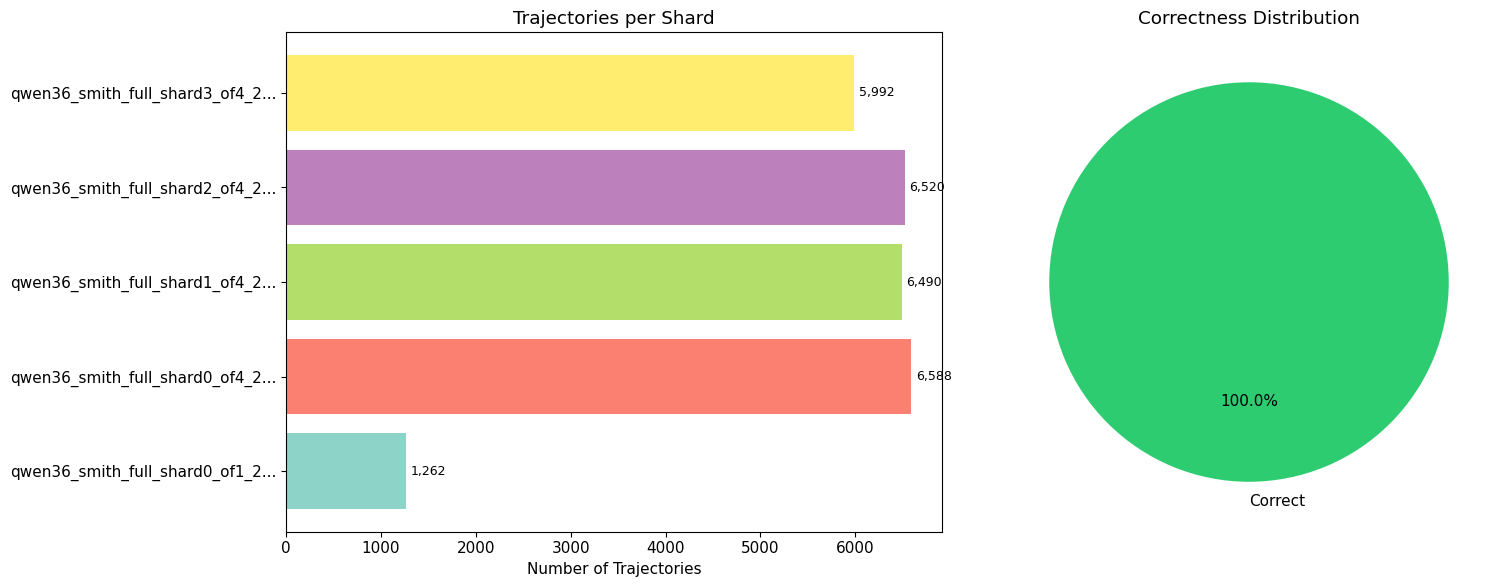

In [10]:
# Visualize: Trajectories per shard (bar chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart: samples per shard
shard_labels = [r['Shard'][:30] + '...' if len(r['Shard']) > 30 else r['Shard'] for r in shard_summary_rows]
shard_counts = [r['#Trajectories'] for r in shard_summary_rows]
colors = plt.cm.Set3(np.linspace(0, 1, len(shard_labels)))

axes[0].barh(shard_labels, shard_counts, color=colors)
axes[0].set_xlabel('Number of Trajectories')
axes[0].set_title('Trajectories per Shard')
for i, v in enumerate(shard_counts):
    axes[0].text(v + 50, i, f'{v:,}', va='center', fontsize=9)

# Pie chart: correctness distribution
correctness_data = [total_correct, total_incorrect, total_unknown]
correctness_labels = ['Correct', 'Incorrect', 'Unknown']
correctness_colors = ['#2ecc71', '#e74c3c', '#95a5a6']
# Filter out zero values
non_zero = [(l, d, c) for l, d, c in zip(correctness_labels, correctness_data, correctness_colors) if d > 0]
if non_zero:
    labels, data, cols = zip(*non_zero)
    axes[1].pie(data, labels=labels, colors=cols, autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Correctness Distribution')

plt.tight_layout()
plt.show()

## 6. Token Length Statistics

In [11]:
# Compute token length statistics per shard
shard_token_stats = defaultdict(lambda: {'total': [], 'system': [], 'user': [], 'assistant': []})

for sample in all_data:
    shard = sample['shard_name']
    msg_info = sample['msg_token_info']
    
    total_tokens = sum(t for _, t in msg_info)
    system_tokens = sum(t for r, t in msg_info if r == 'system')
    user_tokens = sum(t for r, t in msg_info if r == 'user')
    assistant_tokens = sum(t for r, t in msg_info if r == 'assistant')
    
    shard_token_stats[shard]['total'].append(total_tokens)
    shard_token_stats[shard]['system'].append(system_tokens)
    shard_token_stats[shard]['user'].append(user_tokens)
    shard_token_stats[shard]['assistant'].append(assistant_tokens)

# Build summary DataFrame
rows = []
for shard in sorted(shard_token_stats.keys()):
    stats = shard_token_stats[shard]
    row = {'Shard': shard, 'N': len(stats['total'])}
    for category in ['total', 'system', 'user', 'assistant']:
        arr = np.array(stats[category])
        prefix = category.capitalize()
        row[f'{prefix}_Mean'] = int(arr.mean())
        row[f'{prefix}_Min'] = int(arr.min())
        row[f'{prefix}_Max'] = int(arr.max())
    rows.append(row)

df_shard = pd.DataFrame(rows)

# Display as styled DataFrame
display_df = df_shard.set_index('Shard')
col_map = {
    'N': ('Count', 'N'),
    'Total_Mean': ('Total', 'Mean'), 'Total_Min': ('Total', 'Min'), 'Total_Max': ('Total', 'Max'),
    'System_Mean': ('System', 'Mean'), 'System_Min': ('System', 'Min'), 'System_Max': ('System', 'Max'),
    'User_Mean': ('User', 'Mean'), 'User_Min': ('User', 'Min'), 'User_Max': ('User', 'Max'),
    'Assistant_Mean': ('Assistant', 'Mean'), 'Assistant_Min': ('Assistant', 'Min'), 'Assistant_Max': ('Assistant', 'Max'),
}
display_df.columns = pd.MultiIndex.from_tuples([col_map[c] for c in display_df.columns])
display_df

Count  Total                \
                                                       N   Mean   Min     Max   
Shard                                                                           
qwen36_smith_full_shard0_of1_20260604_05.resolv...  1262  34690  3619  167415   
qwen36_smith_full_shard0_of4_20260602.resolved....  6588  26752  2583  170041   
qwen36_smith_full_shard1_of4_20260602.resolved....  6490  26913  3157  245524   
qwen36_smith_full_shard2_of4_20260602.resolved....  6520  27047  2867  146406   
qwen36_smith_full_shard3_of4_20260602.resolved....  5992  26456  2886  184477   

                                                   System         User       \
                                                     Mean Min Max Mean  Min   
Shard                                                                         
qwen36_smith_full_shard0_of1_20260604_05.resolv...     15  15  15  581  285   
qwen36_smith_full_shard0_of4_20260602.resolved....     15  15  15  574  308   
qwen36_smith_full_shard1_of4_20260602.resolved....     15  15  15  572  330   
qwen36_smith_full_shard2_of4_20260602.resolved....     15  15  15  568  285   
qwen36_smith_full_shard3_of4_20260602.resolved....     15  15  15  571  306   

                                                          Assistant          
                                                      Max      Mean Min Max  
Shard                                                                        
qwen36_smith_full_shard0_of1_20260604_05.resolv...   7055         0   0   0  
qwen36_smith_full_shard0_of4_20260602.resolved....   6612         0   0   0  
qwen36_smith_full_shard1_of4_20260602.resolved....  13077         0   0   0  
qwen36_smith_full_shard2_of4_20260602.resolved....   5562         0   0   0  
qwen36_smith_full_shard3_of4_20260602.resolved....   4356         0   0   0

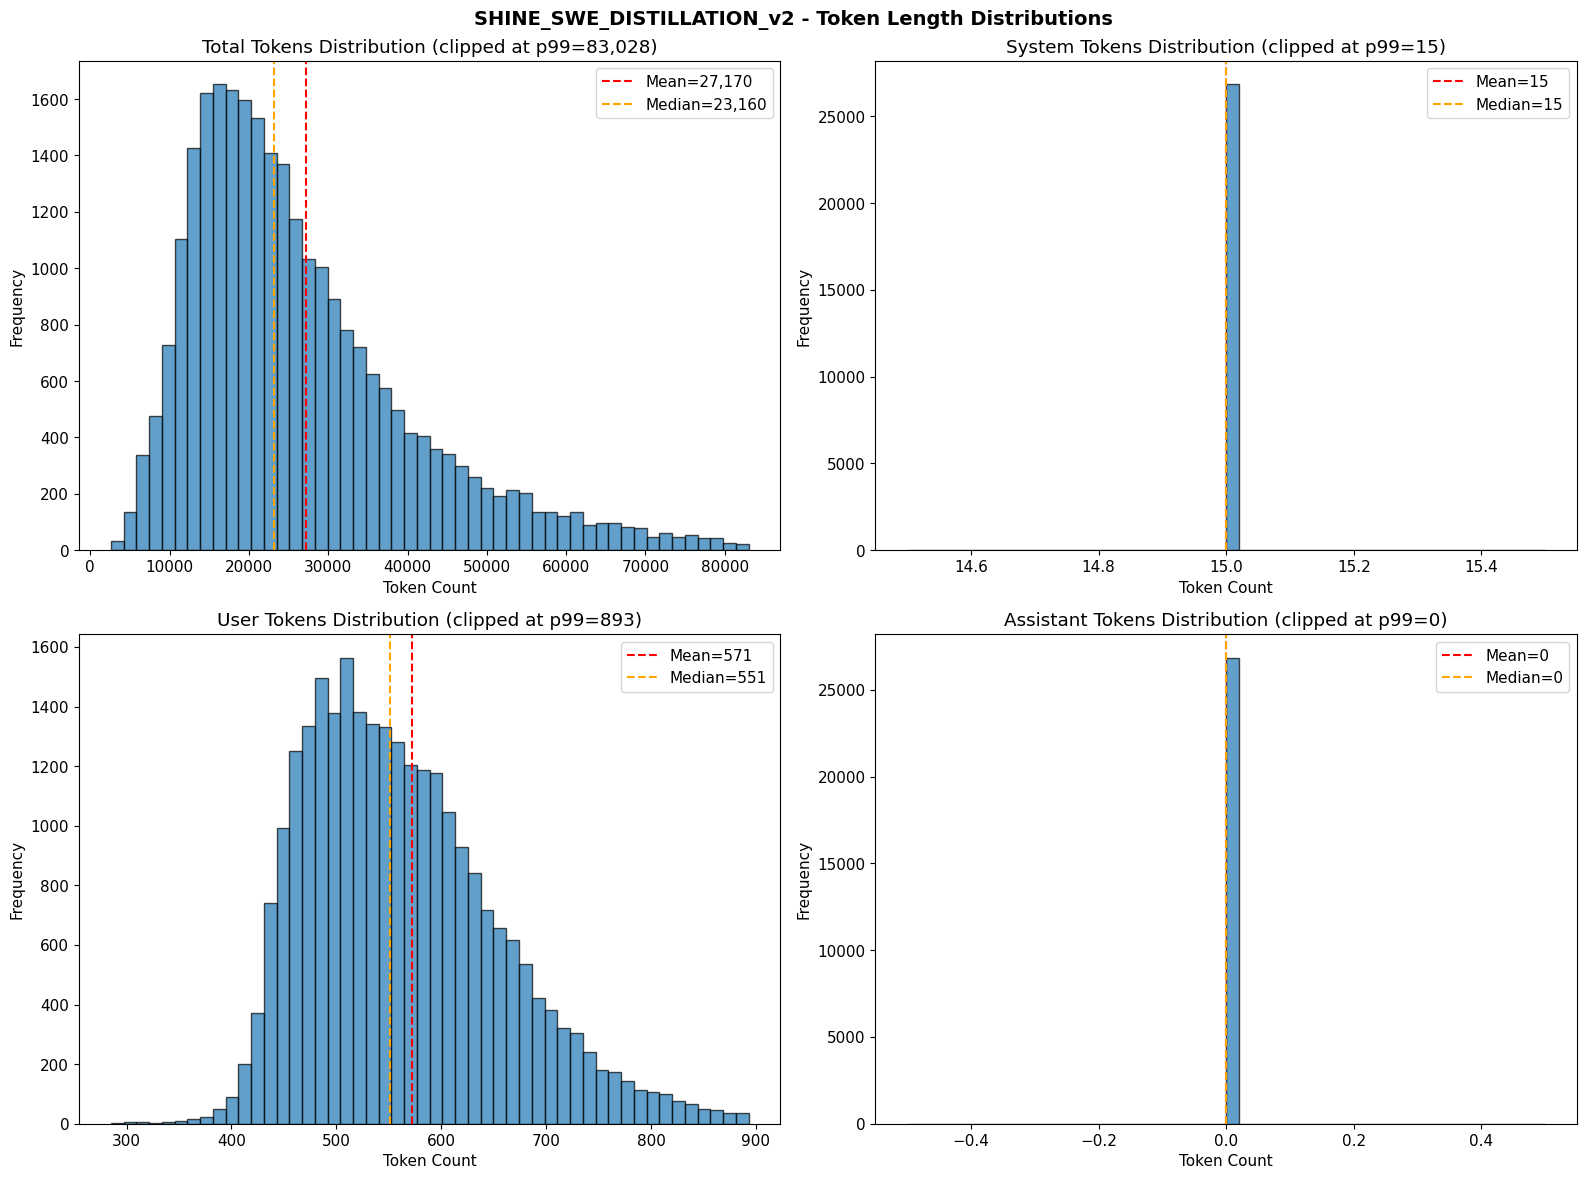

In [12]:
# Token length distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

all_totals = []
all_systems = []
all_users = []
all_assistants = []

for shard in sorted(shard_token_stats.keys()):
    stats = shard_token_stats[shard]
    all_totals.extend(stats['total'])
    all_systems.extend(stats['system'])
    all_users.extend(stats['user'])
    all_assistants.extend(stats['assistant'])

categories = [
    ('Total Tokens', all_totals),
    ('System Tokens', all_systems),
    ('User Tokens', all_users),
    ('Assistant Tokens', all_assistants),
]

for idx, (title, data) in enumerate(categories):
    ax = axes[idx // 2][idx % 2]
    arr = np.array(data)
    # Use percentile-based clipping for better visualization
    p99 = np.percentile(arr, 99)
    clipped = arr[arr <= p99]
    ax.hist(clipped, bins=50, edgecolor='black', alpha=0.7)
    ax.set_title(f'{title} Distribution (clipped at p99={int(p99):,})')
    ax.set_xlabel('Token Count')
    ax.set_ylabel('Frequency')
    ax.axvline(arr.mean(), color='red', linestyle='--', label=f'Mean={int(arr.mean()):,}')
    ax.axvline(np.median(arr), color='orange', linestyle='--', label=f'Median={int(np.median(arr)):,}')
    ax.legend()

plt.suptitle('SHINE_SWE_DISTILLATION_v2 - Token Length Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 7. Top Repos by Trajectory Count

Total unique repos: 108

Top 20 repos by trajectory count:
Repo                                                  Count
------------------------------------------------------------
scanny/python-pptx                                    1,443
sqlfluff/sqlfluff                                     1,063
python-openxml/python-docx                            1,049
cantools/cantools                                     1,029
pylint-dev/astroid                                    1,010
pygments/pygments                                       930
pydicom/pydicom                                         868
seperman/deepdiff                                       840
pallets/jinja                                           779
conan-io/conan                                          687
tobymao/sqlglot                                         664
pyasn1/pyasn1                                           595
oauthlib/oauthlib                                       591
python-trio/trio                        

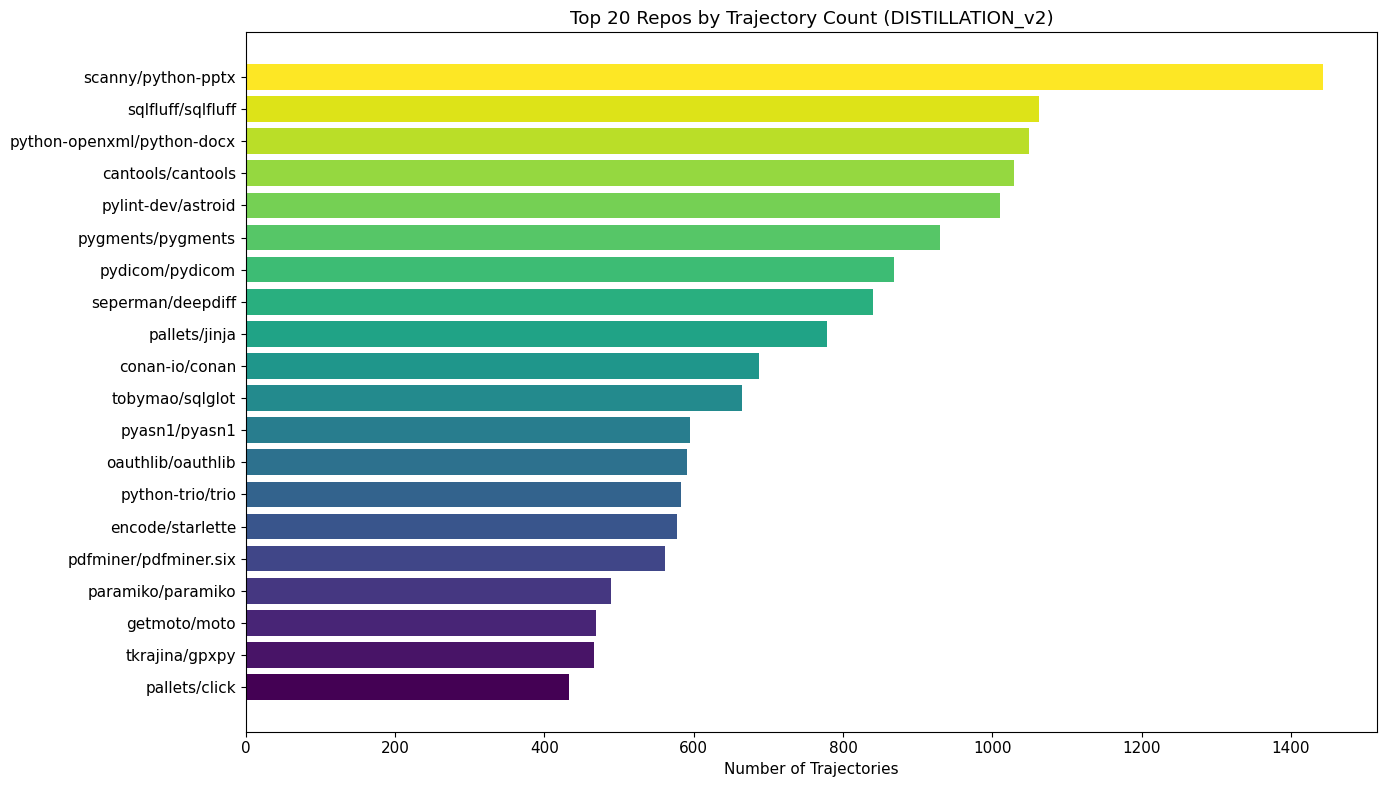

In [13]:
# Top repos by number of trajectories
repo_counts = Counter(s['repo'] for s in all_data)
top_repos = repo_counts.most_common(20)

print(f'Total unique repos: {len(repo_counts)}')
print(f'\nTop 20 repos by trajectory count:')
print(f'{"Repo":<50} {"Count":>8}')
print('-' * 60)
for repo, count in top_repos:
    print(f'{repo:<50} {count:>8,}')

# Visualize top repos
fig, ax = plt.subplots(figsize=(14, 8))
repos_labels = [r[0][:40] for r in top_repos]
repos_values = [r[1] for r in top_repos]
ax.barh(repos_labels[::-1], repos_values[::-1], color=plt.cm.viridis(np.linspace(0, 1, len(top_repos))))
ax.set_xlabel('Number of Trajectories')
ax.set_title('Top 20 Repos by Trajectory Count (DISTILLATION_v2)')
plt.tight_layout()
plt.show()

## 8. Comparison with v1

Quick summary of key differences from SHINE_SWE_DISTILLATION (v1):
- **v1**: 3 shards, 19,598 samples, no issue extraction fields
- **v2**: 5 shards, ~27,018 samples (+37.9%), with issue_content/title/hash fields
- **New shard**: `shard0_of1_20260604_05` is an incremental deduplicated merge from newer runs
- **Deduplication**: All samples have unique `issue_content_hash` within each shard

In [14]:
# Summary comparison table
comparison = pd.DataFrame({
    'Metric': ['Total Shards', 'Total Samples', 'Unique Repos', 'Has issue_content', 'Has issue_title', 'Has issue_content_hash', 'All Correct'],
    'v1': [3, 19598, 105, 'No', 'No', 'No', 'Yes (all resolved)'],
    'v2': [len(shard_summary_rows), total_all, total_repos, 
           f'{sum(s["has_content"] for s in issue_stats.values()):,}',
           f'{sum(s["has_title"] for s in issue_stats.values()):,}',
           f'{sum(s["has_hash"] for s in issue_stats.values()):,}',
           'Yes (all resolved)']
})
print(comparison.to_string(index=False))

                Metric                 v1                 v2
          Total Shards                  3                  5
         Total Samples              19598              26852
          Unique Repos                105                108
     Has issue_content                 No             26,852
       Has issue_title                 No             26,506
Has issue_content_hash                 No             26,852
           All Correct Yes (all resolved) Yes (all resolved)
